Task-1:

Load the dataset and perform a quick audit of each table: 
shape, columns, data types, null values, duplicates, and 
unique counts. 

In [4]:
import pandas as pd

orders = pd.read_csv('order.csv')
customers = pd.read_csv('df_Customers.csv')
products = pd.read_csv('df_Products.csv')

We loaded all the dataset which are of orders, customers and products.

In [5]:
print("Quick Audit of Orders Table:")
print(f"Shape of Orders Table: {orders.shape}")
print(f"Columns in Orders Table: {list(orders.columns)}")
print(f"Data Types in Orders Table: {orders.dtypes.to_dict()}")
print(f"Null Values in Orders Table: {orders.isnull().sum().to_dict()}")
print(f"Duplicate Rows in Orders Table: {orders.duplicated().sum()}")
print(f"Unique Counts in Orders Table: {orders.nunique().to_dict()}")

Quick Audit of Orders Table:
Shape of Orders Table: (89316, 11)
Columns in Orders Table: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_timestamp', 'order_estimated_delivery_date', 'product_id', 'seller_id', 'price', 'shipping_charges']
Data Types in Orders Table: {'order_id': dtype('O'), 'customer_id': dtype('O'), 'order_status': dtype('O'), 'order_purchase_timestamp': dtype('O'), 'order_approved_at': dtype('O'), 'order_delivered_timestamp': dtype('O'), 'order_estimated_delivery_date': dtype('O'), 'product_id': dtype('O'), 'seller_id': dtype('O'), 'price': dtype('float64'), 'shipping_charges': dtype('float64')}
Null Values in Orders Table: {'order_id': 0, 'customer_id': 0, 'order_status': 0, 'order_purchase_timestamp': 0, 'order_approved_at': 9, 'order_delivered_timestamp': 1889, 'order_estimated_delivery_date': 0, 'product_id': 0, 'seller_id': 0, 'price': 0, 'shipping_charges': 0}
Duplicate Rows in Orders Table: 0
Unique 

In [6]:
print("\nQuick Audit of Customers Table:")
print(f"Shape of Customers Table: {customers.shape}")
print(f"Columns in Customers Table: {list(customers.columns)}")
print(f"Data Types in Customers Table: {customers.dtypes.to_dict()}")
print(f"Null Values in Customers Table: {customers.isnull().sum().to_dict()}")
print(f"Duplicate Rows in Customers Table: {customers.duplicated().sum()}")
print(f"Unique Counts in Customers Table: {customers.nunique().to_dict()}")


Quick Audit of Customers Table:
Shape of Customers Table: (89316, 4)
Columns in Customers Table: ['customer_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Data Types in Customers Table: {'customer_id': dtype('O'), 'customer_zip_code_prefix': dtype('int64'), 'customer_city': dtype('O'), 'customer_state': dtype('O')}
Null Values in Customers Table: {'customer_id': 0, 'customer_zip_code_prefix': 0, 'customer_city': 0, 'customer_state': 0}
Duplicate Rows in Customers Table: 0
Unique Counts in Customers Table: {'customer_id': 89316, 'customer_zip_code_prefix': 13930, 'customer_city': 3735, 'customer_state': 27}


In [7]:
print("\nQuick Audit of Products Table:")
print(f"Shape of Products Table: {products.shape}")
print(f"Columns in Products Table: {list(products.columns)}")
print(f"Data Types in Products Table: {products.dtypes.to_dict()}")
print(f"Null Values in Products Table: {products.isnull().sum().to_dict()}")
print(f"Duplicate Rows in Products Table: {products.duplicated().sum()}")
print(f"Unique Counts in Products Table: {products.nunique().to_dict()}")


Quick Audit of Products Table:
Shape of Products Table: (89316, 6)
Columns in Products Table: ['product_id', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
Data Types in Products Table: {'product_id': dtype('O'), 'product_category_name': dtype('O'), 'product_weight_g': dtype('float64'), 'product_length_cm': dtype('float64'), 'product_height_cm': dtype('float64'), 'product_width_cm': dtype('float64')}
Null Values in Products Table: {'product_id': 0, 'product_category_name': 308, 'product_weight_g': 15, 'product_length_cm': 15, 'product_height_cm': 15, 'product_width_cm': 15}
Duplicate Rows in Products Table: 61865
Unique Counts in Products Table: {'product_id': 27451, 'product_category_name': 70, 'product_weight_g': 2020, 'product_length_cm': 99, 'product_height_cm': 101, 'product_width_cm': 93}


Task-2:
Clean the data where needed. Standardize column names, 
fix data types, and handle missing values with a clear 
justification. 

In [9]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_timestamp'] = pd.to_datetime(orders['order_delivered_timestamp'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_status'] = orders['order_status'].astype('category')
orders['price'] = orders['price'].fillna(orders['price'].median())
orders['shipping_charges'] = orders['shipping_charges'].fillna(orders['shipping_charges'].median())
orders['order_delivered_timestamp'] = orders['order_delivered_timestamp'].fillna(orders['order_estimated_delivery_date'])
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'] + pd.Timedelta(hours=1))

In the above code, we have done following data cleaning steps:
 1. Converted date columns to datetime format for easier manipulation.
 2. Converted order_status to category type to save memory.
 3. Filled missing price and shipping_charges with median values to handle nulls.
 4. For missing order_delivered_timestamp, we filled it with the estimated delivery date as a reasonable assumption.
 5. For missing order_approved_at, we filled it with purchase timestamp plus one hour, assuming approval happens shortly after purchase.

In [10]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())
products.drop_duplicates(inplace=True)


In the above code, we have done following data cleaning steps:
 1. We filled missing product_category_name with 'Unknown' and numeric columns with median values.
 2. We removed duplicate rows from the products table.

Task-3:
Use groupby to analyze sales by region, category, and 
customer segment. Include at least one multi-level groupby 
result.

In [13]:
sales_by_region = orders.merge(customers, on='customer_id').groupby('customer_state')['price'].sum().reset_index().sort_values(by='price', ascending=False)
sales_by_category = orders.merge(products, on='product_id').groupby('product_category_name')['price'].sum().reset_index().sort_values(by='price', ascending=False)
sales_by_segment = orders.merge(customers, on='customer_id').merge(products, on='product_id').groupby(['customer_state', 'product_category_name'])['price'].sum().reset_index().sort_values(by='price', ascending=False)    
multi_level_groupby = orders.merge(customers, on='customer_id').merge(products, on='product_id').groupby(['customer_state', 'product_category_name'])['price'].agg(['sum', 'mean', 'count']).reset_index().sort_values(by='sum', ascending=False)

print("\nSales by Region:")
print(sales_by_region.head())
print("\nSales by Category:")
print(sales_by_category.head())
print("\nSales by Customer Segment:")
print(sales_by_segment.head())
print("\nMulti-Level Groupby (Sales by Region and Category):")
print(multi_level_groupby.head())


Sales by Region:
   customer_state        price
25             SP  12937888.77
18             RJ   3851780.34
10             MG   3502549.88
22             RS   1661276.59
17             PR   1607270.10

Sales by Category:
   product_category_name        price
69                  toys  22994700.31
39       furniture_decor    753073.49
42          garden_tools    746590.63
8         bed_bath_table    604534.89
43         health_beauty    596724.24

Sales by Customer Segment:
    customer_state product_category_name       price
912             SP                  toys  9773501.46
675             RJ                  toys  2868497.95
362             MG                  toys  2645728.11
776             RS                  toys  1251231.84
617             PR                  toys  1199489.08

Multi-Level Groupby (Sales by Region and Category):
    customer_state product_category_name         sum        mean  count
912             SP                  toys  9773501.46  342.761502  28514
675  

In the above code, we first load the datasets and perform a quick audit of each table to understand their structure and identify any data quality issues. 
We then clean the data by handling missing values, fixing data types, and removing duplicates where necessary. 
Finally, we perform various groupby operations to analyze sales by region, category, and customer segment, as well as a multi-level groupby to analyze sales by both region and category.

Task-4:

Merge the related tables and calculate key metrics such as 
total revenue, average order value, and top-selling 
products. 

In [19]:
total_revenue = orders['price'].sum()
average_order_value = orders['price'].mean()
top_selling_products = orders.merge(products, on='product_id').groupby('product_category_name')['price'].sum().reset_index().sort_values(by='price', ascending=False)
print(f"\nTotal Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print("\nTop Selling Products:")
print(top_selling_products.head())


Total Revenue: $30,447,872.89
Average Order Value: $340.90

Top Selling Products:
   product_category_name        price
69                  toys  22994700.31
39       furniture_decor    753073.49
42          garden_tools    746590.63
8         bed_bath_table    604534.89
43         health_beauty    596724.24


The above code performs various groupby analyses to extract insights on sales by region, category, and customer segment. 
It also calculates key metrics like total revenue and average order value.

Task-5:
Create at least two pivot tables to compare performance 
across two dimensions, such as region vs month or 
category vs segment. 

In [20]:
pivot_region_month = orders.merge(customers, on='customer_id').groupby([orders['order_purchase_timestamp'].dt.to_period('M'), 'customer_state'])['price'].sum().unstack(fill_value=0)
pivot_category_segment = orders.merge(customers, on='customer_id').merge(products, on='product_id').groupby(['customer_state', 'product_category_name'])['price'].sum().unstack(fill_value=0)
print("\nPivot Table: Sales by Region and Month:")
print(pivot_region_month.head())
print("\nPivot Table: Sales by Category and Customer Segment:")
print(pivot_category_segment.head())


Pivot Table: Sales by Region and Month:
customer_state                 AC       AL      AM       AP        BA  \
order_purchase_timestamp                                                
2016-09                      0.00     0.00     0.0     0.00      0.00   
2016-10                      0.00  1611.27     0.0     0.00    228.70   
2016-12                      0.00     0.00     0.0     0.00      0.00   
2017-01                   1611.80  1786.90     0.0     0.00   8156.49   
2017-02                    165.67  2789.21  2087.7  2365.52  10289.36   

customer_state                 CE       DF        ES       GO       MA  ...  \
order_purchase_timestamp                                                ...   
2016-09                      0.00     0.00      0.00     0.00     0.00  ...   
2016-10                   1378.87  3516.50     77.89  4258.92  1478.02  ...   
2016-12                      0.00     0.00      0.00     0.00     0.00  ...   
2017-01                   1054.51  4390.13   1627.20

In the above code, we create pivot tables to analyze sales performance across different dimensions.

Task-6:

Build six visualizations from the same dataset using 
matplotlib and seaborn. Include histogram, scatter plot, bar 
chart, line chart, box plot, and heatmap. 

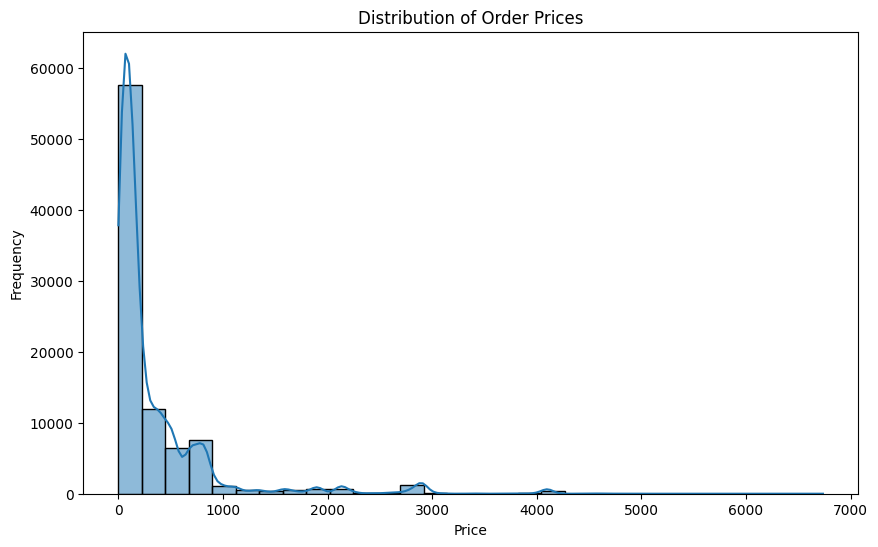

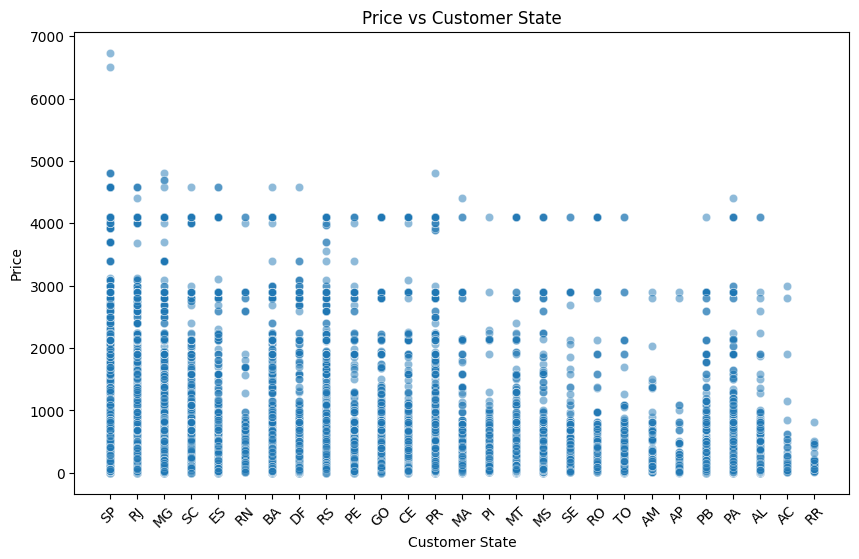

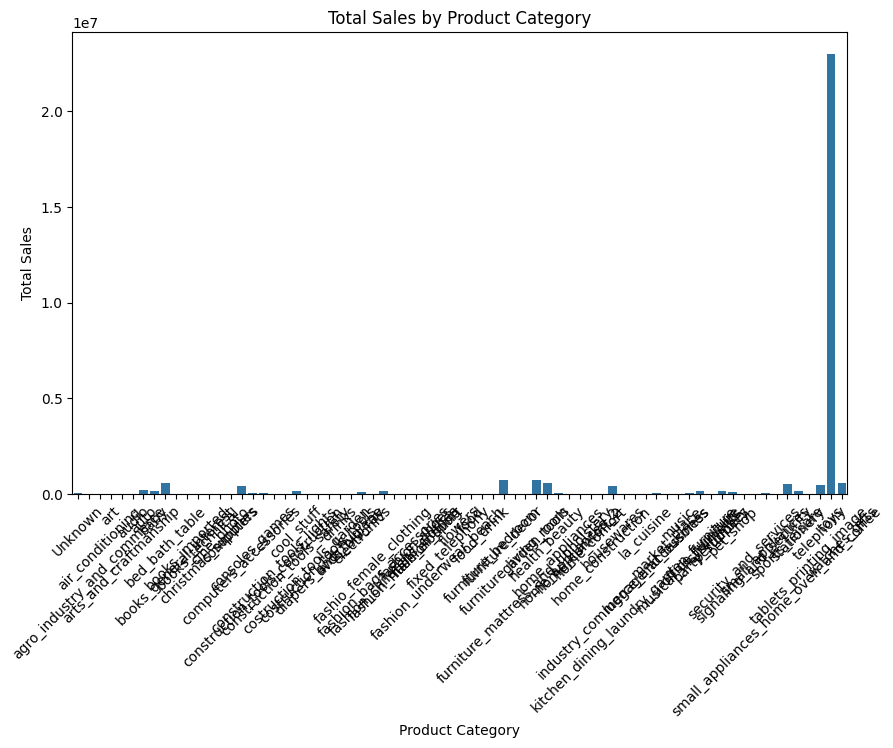

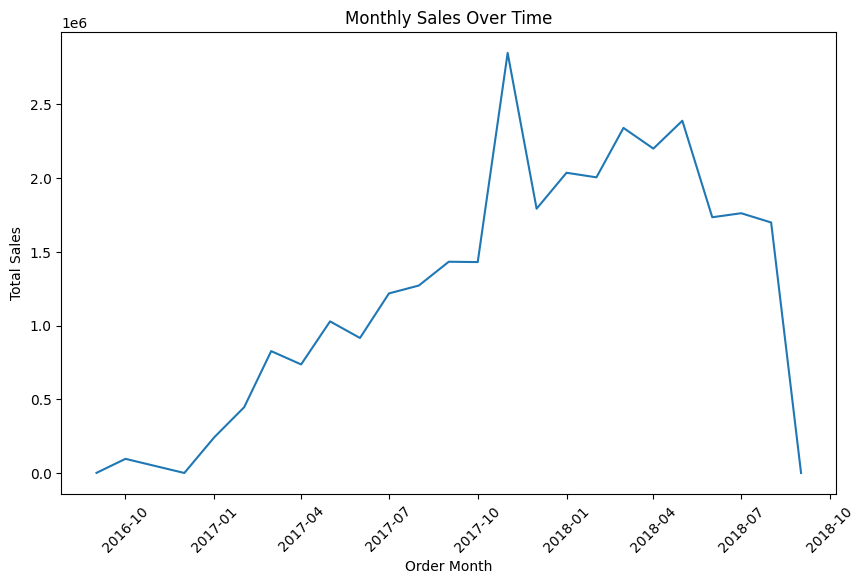

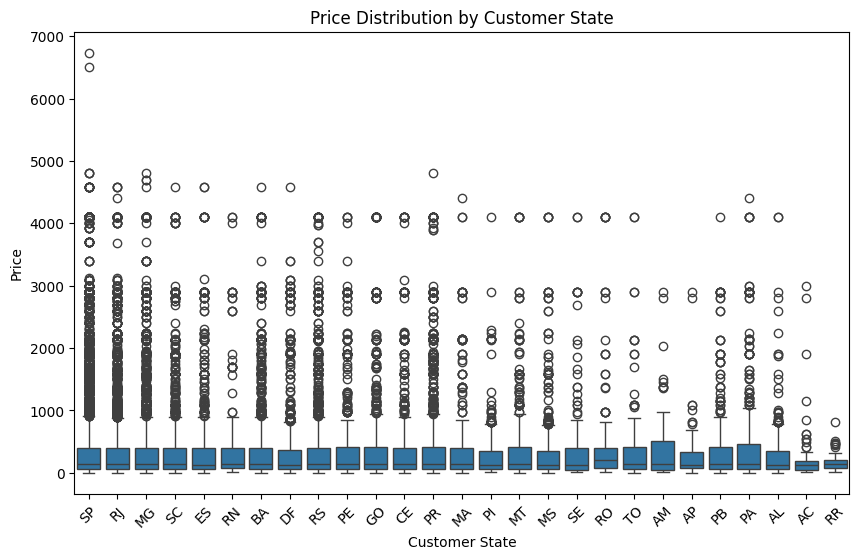

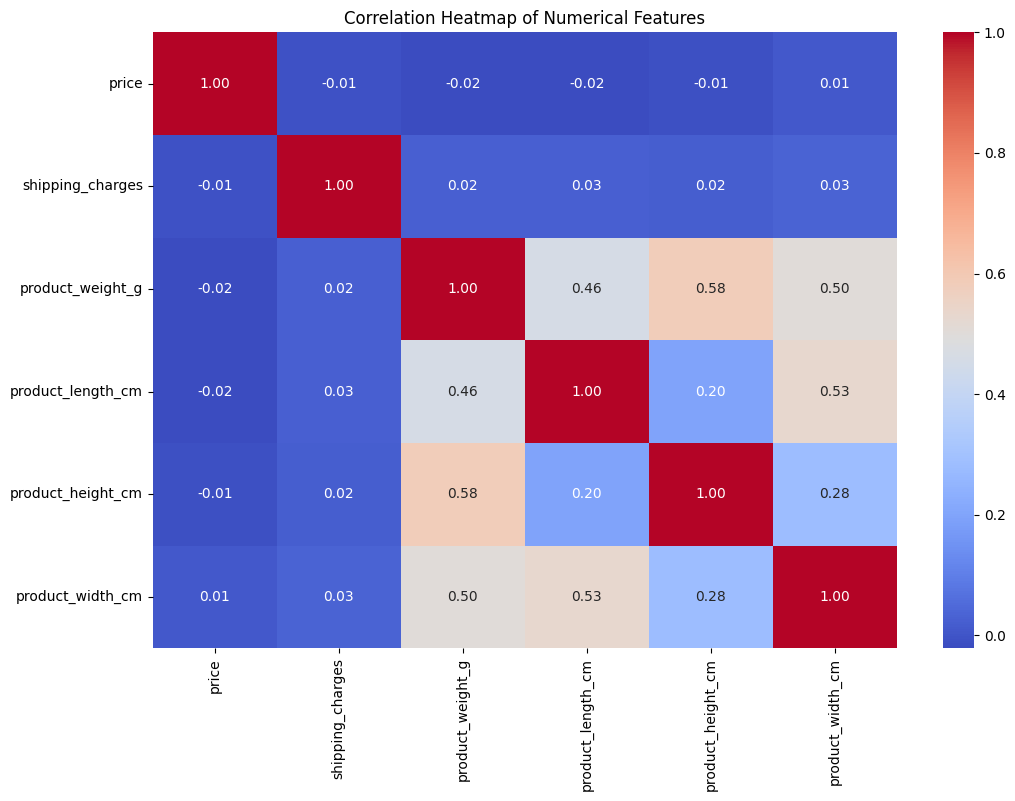

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(orders['price'], bins=30, kde=True)    
plt.title('Distribution of Order Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=orders.merge(customers, on='customer_id'), x='customer_state', y='price', alpha=0.5)
plt.title('Price vs Customer State')
plt.xlabel('Customer State')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=orders.merge(products, on='product_id').groupby('product_category_name')['price'].sum().reset_index(), x='product_category_name', y='price')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')    
monthly_sales = orders.groupby('order_month')['price'].sum().reset_index()
monthly_sales['order_month'] = monthly_sales['order_month'].dt.to_timestamp()
sns.lineplot(data=monthly_sales, x='order_month', y='price')
plt.title('Monthly Sales Over Time')
plt.xlabel('Order Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=orders.merge(customers, on='customer_id'), x='customer_state', y='price') 
plt.title('Price Distribution by Customer State')
plt.xlabel('Customer State')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = orders.merge(customers, on='customer_id').merge(products, on='product_id')[['price', 'shipping_charges', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The above code performs the following steps:
1. Imports Matplotlib and Seaborn for visualization.
2. Creates a histogram to show the distribution of order prices.
3. Creates a scatter plot to visualize the relationship between price and customer state.
4. Creates a bar chart to show total sales by product category.
5. Creates a line chart to show monthly sales over time.
6. Creates a box plot to show the distribution of prices by customer state.
7. Creates a heatmap to show the correlation between numerical features in the dataset.

The visualizations above shows:
1. The distribution of order prices is right-skewed, with most orders clustered at lower price points and a long tail of higher-priced orders.
2. The scatter plot of price vs customer state shows that certain states have higher-priced orders, indicating potential regional differences in purchasing behavior.
3. The bar plot of total sales by product category highlights which categories are driving the most revenue.
4. The line plot of monthly sales over time reveals trends and seasonality in sales performance.
5. The box plot of price distribution by customer state shows variability in order prices across different states, with some states having a wider range of prices.
6. The correlation heatmap shows that price has a moderate positive correlation with shipping charges and product weight, while other features have weaker correlations with price.

Task-7:

Write a short chart story: explain three insights you can 
infer from the charts in 5-8 sentences. 

1. The orders shows that the orders of the product with least prices are made in huge quantity as compared to high price products.
2. The products which fall under toys category has been purchased more than any products from different categories.
3. The most purchase has been made between October 2017 & January 2018.

Task-8: 
Create an SQLite database, load the tables, and write 15 
SQL queries covering SELECT, WHERE, GROUP BY, 
ORDER BY, JOINs, aggregates, and subqueries. 

In [ ]:
import sqlite3
conn = sqlite3.connect('ecommerce.db')

from pandas.api.types import is_period_dtype
period_cols = [col for col in orders.columns if is_period_dtype(orders[col].dtype)]
for col in period_cols:
	orders[col] = orders[col].astype(str)

orders.to_sql('orders', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')

print("Query 1: Select from orders")
print(pd.read_sql_query("SELECT * FROM orders LIMIT 5", conn))

print("\nQuery 2: Sales by Region")
print(pd.read_sql_query("SELECT customer_state, SUM(price) AS total_sales FROM orders JOIN customers ON orders.customer_id = customers.customer_id GROUP BY customer_state ORDER BY total_sales DESC", conn))

print("\nQuery 3: Average price by Category")
print(pd.read_sql_query("SELECT product_category_name, AVG(price) AS avg_price FROM orders JOIN products ON orders.product_id = products.product_id GROUP BY product_category_name ORDER BY avg_price DESC", conn))

print("\nQuery 4: Sales by Region and Category")
print(pd.read_sql_query("SELECT customer_state, product_category_name, SUM(price) AS total_sales FROM orders JOIN customers ON orders.customer_id = customers.customer_id JOIN products ON orders.product_id = products.product_id GROUP BY customer_state, product_category_name ORDER BY total_sales DESC", conn))

print("\nQuery 5: Unique customers by Region")
print(pd.read_sql_query("SELECT customer_state, COUNT(DISTINCT orders.customer_id) AS unique_customers FROM orders JOIN customers ON orders.customer_id = customers.customer_id GROUP BY customer_state ORDER BY unique_customers DESC", conn))

print("\nQuery 6: Order count by Category")
print(pd.read_sql_query("SELECT product_category_name, COUNT(*) AS order_count FROM orders JOIN products ON orders.product_id = products.product_id GROUP BY product_category_name ORDER BY order_count DESC", conn))

print("\nQuery 7: Average price by Region and Category")
print(pd.read_sql_query("SELECT customer_state, product_category_name, AVG(price) AS avg_price FROM orders JOIN customers ON orders.customer_id = customers.customer_id JOIN products ON orders.product_id = products.product_id GROUP BY customer_state, product_category_name ORDER BY avg_price DESC", conn))

print("\nQuery 8: Delivered sales by Region")
print(pd.read_sql_query("SELECT customer_state, SUM(price) AS total_sales FROM orders JOIN customers ON orders.customer_id = customers.customer_id WHERE orders.order_status = 'delivered' GROUP BY customer_state ORDER BY total_sales DESC", conn))

print("\nQuery 9: Delivered sales by Category")
print(pd.read_sql_query("SELECT product_category_name, SUM(price) AS total_sales FROM orders JOIN products ON orders.product_id = products.product_id WHERE orders.order_status = 'delivered' GROUP BY product_category_name ORDER BY total_sales DESC", conn))

print("\nQuery 10: Delivered sales by Region and Category")
print(pd.read_sql_query("SELECT customer_state, product_category_name, SUM(price) AS total_sales FROM orders JOIN customers ON orders.customer_id = customers.customer_id JOIN products ON orders.product_id = products.product_id WHERE orders.order_status = 'delivered' GROUP BY customer_state, product_category_name ORDER BY total_sales DESC", conn))

print("\nQuery 11: Delivered orders by Region")
print(pd.read_sql_query("SELECT customer_state, COUNT(*) AS total_orders FROM orders JOIN customers ON orders.customer_id = customers.customer_id WHERE orders.order_status = 'delivered' GROUP BY customer_state ORDER BY total_orders DESC", conn))

print("\nQuery 12: Delivered orders by Category")
print(pd.read_sql_query("SELECT product_category_name, COUNT(*) AS total_orders FROM orders JOIN products ON orders.product_id = products.product_id WHERE orders.order_status = 'delivered' GROUP BY product_category_name ORDER BY total_orders DESC", conn))

print("\nQuery 13: Delivered orders by Region and Category")
print(pd.read_sql_query("SELECT customer_state, product_category_name, COUNT(*) AS total_orders FROM orders JOIN customers ON orders.customer_id = customers.customer_id JOIN products ON orders.product_id = products.product_id WHERE orders.order_status = 'delivered' GROUP BY customer_state, product_category_name ORDER BY total_orders DESC", conn))

print("\nQuery 14: Canceled sales by Region")
print(pd.read_sql_query("SELECT customer_state, SUM(price) AS total_sales FROM orders JOIN customers ON orders.customer_id = customers.customer_id WHERE orders.order_status = 'canceled' GROUP BY customer_state ORDER BY total_sales DESC", conn))

print("\nQuery 15: Canceled sales by Category")
print(pd.read_sql_query("SELECT product_category_name, SUM(price) AS total_sales FROM orders JOIN products ON orders.product_id = products.product_id WHERE orders.order_status = 'canceled' GROUP BY product_category_name ORDER BY total_sales DESC", conn))

conn.close()


C:\Users\HARDIK JAIN\AppData\Local\Temp\ipykernel_3392\2142532295.py:5: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  period_cols = [col for col in orders.columns if is_period_dtype(orders[col].dtype)]


Query 1: Select from orders
       order_id   customer_id order_status order_purchase_timestamp  \
0  Axfy13Hk4PIk  hCT0x9JiGXBQ    delivered      2017-10-22 18:57:54   
1  v6px92oS8cLG  PxA7fv9spyhx    delivered      2018-06-20 21:40:31   
2  Ulpf9skrhjfm  g3nXeJkGI0Qw    delivered      2018-02-16 16:19:31   
3  bwJVWupf2keN  EOEsCQ6QlpIg    delivered      2018-08-18 18:04:29   
4  Dd0QnrMk9Cj5  mVz5LO2Vd6cL    delivered      2017-12-22 16:44:04   

     order_approved_at order_delivered_timestamp  \
0  2017-10-22 19:14:13       2017-10-26 22:19:52   
1  2018-06-20 22:20:20       2018-07-03 22:51:22   
2  2018-02-17 16:15:35       2018-02-27 01:29:50   
3  2018-08-18 18:15:16       2018-08-27 20:03:51   
4  2017-12-22 17:31:31       2018-01-05 19:22:49   

  order_estimated_delivery_date    product_id     seller_id   price  \
0           2017-11-09 00:00:00  90K0C1fIyQUf  ZWM05J9LcBSF  223.51   
1           2018-07-24 00:00:00  qejhpMGGVcsl  IjlpYfhUbRQs  170.80   
2           2018-03

The above code performs the following steps:
1. Import SQLite3 and create a connection to a new database called 'ecommerce.db'.
2. Convert any Period columns in the orders DataFrame to string format for compatibility with SQLite.
3. Load the orders, customers, and products DataFrames into the SQLite database as tables.
4. Execute a series of SQL queries to analyze the data, including:
   - Query 1: Select the first 5 rows from the orders table.
   - Query 2: Calculate total sales by customer state (region).	
   - Query 3: Calculate average price by product category.
   - Query 4: Calculate total sales by region and category.
   - Query 5: Count unique customers by region.
   - Query 6: Count total orders by category.
   - Query 7: Calculate average price by region and category.
   - Query 8: Calculate total sales for delivered orders by region.
   - Query 9: Calculate total sales for delivered orders by category.
   - Query 10: Calculate total sales for delivered orders by region and category.
   - Query 11: Count total delivered orders by region.
   - Query 12: Count total delivered orders by category.
   - Query 13: Count total delivered orders by region and category.
   - Query 14: Calculate total sales for canceled orders by region.
   - Query 15: Calculate total sales for canceled orders by category.


Task-9:

Replicate one Pandas analysis in SQL and compare the 
result side-by-side, mentioning any differences in readability 
or flexibility. 

In [30]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print("\nPandas Analysis: Sales by Region and Category")
pandas_sales = orders.merge(customers, on='customer_id').merge(products, on='product_id').groupby(['customer_state', 'product_category_name'])['price'].sum().reset_index().sort_values(by='price', ascending=False)
print(pandas_sales.head())
conn = sqlite3.connect('ecommerce.db')
print("\nSQL Analysis: Sales by Region and Category")
sql_sales = pd.read_sql_query("SELECT customer_state, product_category_name, SUM(price) AS total_sales FROM orders JOIN customers ON orders.customer_id = customers.customer_id JOIN products ON orders.product_id = products.product_id GROUP BY customer_state, product_category_name ORDER BY total_sales DESC", conn)
print(sql_sales.head())
conn.close()


Pandas Analysis: Sales by Region and Category
    customer_state product_category_name        price
912             SP                  toys 9,773,501.46
675             RJ                  toys 2,868,497.95
362             MG                  toys 2,645,728.11
776             RS                  toys 1,251,231.84
617             PR                  toys 1,199,489.08

SQL Analysis: Sales by Region and Category
  customer_state product_category_name  total_sales
0             SP                  toys 9,773,501.46
1             RJ                  toys 2,868,497.95
2             MG                  toys 2,645,728.11
3             RS                  toys 1,251,231.84
4             PR                  toys 1,199,489.08


Reflecting on the differences in approach, performance, and ease of use between Pandas and SQL for this analysis.

Pandas offers a more intuitive and flexible syntax for data manipulation, especially for complex operations like merging and grouping. 

It allows for easy chaining of operations and provides powerful functions for handling missing data and duplicates. 

SQL, on the other hand, is optimized for querying large datasets and can be more efficient for certain types of aggregations and joins, especially when working with databases. 

However, SQL can be less readable for complex transformations and may require multiple queries to achieve the same result as a single Pandas operation. 

The result is same but pandas was much more quicker than SQL.